# Modelo de regresion logistica para dataset de abandono de clientes
https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3?resource=download

Presentado por: Diego Orjuela - Alex Rodriguez - Ana Salcedo

## 1. Configuración Inicial y Adquisición de Datos

In [100]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import joblib

# Preparación de datos
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler

# Evaluación
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    precision_score, recall_score
)

# Sistema
import os
import sys
import requests
import warnings
warnings.filterwarnings('ignore')


In [101]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/Churn/master/'


# Nombres de los archivos requeridos
DATASET_FILE_NAME = 'telco_Prep.csv'  # Incluye la carpeta datasets
UTILS_FILE_NAME = 'funciones.py'         # Incluye la carpeta utils


# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = GITHUB_BASE_URL + 'datasets/' + DATASET_FILE_NAME
github_utils_url = GITHUB_BASE_URL + 'utils/' + UTILS_FILE_NAME

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [102]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [103]:
## Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/Churn/master/datasets/telco_Prep.csv
dataset descargado exitosamente a: datasets/telco_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/Smartdvis17/Churn/master/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones Auxiliares

In [104]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importa Funciones externas
from funciones import multiple_plot

#### Cargamos el dataset que limpiamos en la fase 1 de limpieza de datos

In [105]:
#Cargar el dataset
df = pd.read_csv(local_dataset_path)

In [106]:
#Previsualización de los datos
df.head()

,Gender,Age,Senior Citizen,Married,Number of Dependents,Zip Code,Latitude,Longitude,Population,Referred a Friend,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV
0,Male,73,Yes,Yes,0,96145,39.1783,-120.1628,4002,Yes,...,2357.7500,0.0000,0,1065.7500,3423.5000,3,Stayed,No,67,2217
1,Male,42,No,No,0,95545,40.3429,-124.0633,82,No,...,19.4500,0.0000,0,48.9600,68.4100,2,Churned,Yes,78,5687
2,Male,57,No,Yes,0,95528,40.4973,-123.9304,1072,Yes,...,1125.2000,0.0000,0,360.9900,1486.1900,3,Stayed,No,43,5763
3,Female,35,No,No,0,90743,33.7283,-118.0853,174,No,...,578.5000,0.0000,0,278.1000,856.6000,3,Stayed,No,78,3986
4,Female,28,No,No,0,92231,32.6907,-115.4312,27804,No,...,1343.4000,30.5300,0,1549.0400,2861.9100,5,Stayed,No,72,5462


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             6326 non-null   str    
 1   Age                                6326 non-null   int64  
 2   Senior Citizen                     6326 non-null   str    
 3   Married                            6326 non-null   str    
 4   Number of Dependents               6326 non-null   int64  
 5   Zip Code                           6326 non-null   int64  
 6   Latitude                           6326 non-null   float64
 7   Longitude                          6326 non-null   float64
 8   Population                         6326 non-null   int64  
 9   Referred a Friend                  6326 non-null   str    
 10  Number of Referrals                6326 non-null   int64  
 11  Tenure in Months                   6326 non-null   int64  
 12  Off

In [108]:
df_over = df.copy()

## 3. Visualización de datos

### Variables de entrada

In [109]:
#Listamos las variables categóricas
catCols = df.select_dtypes(include = ["object", 'category']).columns.tolist()

df[catCols].head(2)

,Gender,Senior Citizen,Married,Referred a Friend,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,...,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Churn Label
0,Male,Yes,Yes,Yes,Offer C,Yes,Yes,Yes,Fiber Optic,No,...,No,No,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal,Stayed,No
1,Male,No,No,No,Offer E,Yes,No,No,No internet,No,...,No,No,No,No,No,Month-to-Month,Yes,Credit Card,Churned,Yes


In [110]:
#Listamos las variables numéricas

numCols=df.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
df[numCols].head()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
0,73,0,96145,39.1783,-120.1628,4002,7,29,36.7500,12,84.3000,2357.7500,0.0000,0,1065.7500,3423.5000,3,67,2217
1,42,0,95545,40.3429,-124.0633,82,0,1,48.9600,0,19.4500,19.4500,0.0000,0,48.9600,68.4100,2,78,5687
2,57,0,95528,40.4973,-123.9304,1072,4,21,17.1900,11,54.6000,1125.2000,0.0000,0,360.9900,1486.1900,3,43,5763
3,35,0,90743,33.7283,-118.0853,174,0,30,9.2700,0,19.4000,578.5000,0.0000,0,278.1000,856.6000,3,78,3986
4,28,0,92231,32.6907,-115.4312,27804,0,67,23.1200,0,20.5500,1343.4000,30.5300,0,1549.0400,2861.9100,5,72,5462


### Variable de salida

In [111]:
df.groupby('Churn Label')['Churn Label'].count().sort_values(ascending=False)

Churn Label
No     4641
Yes    1685
Name: Churn Label, dtype: int64

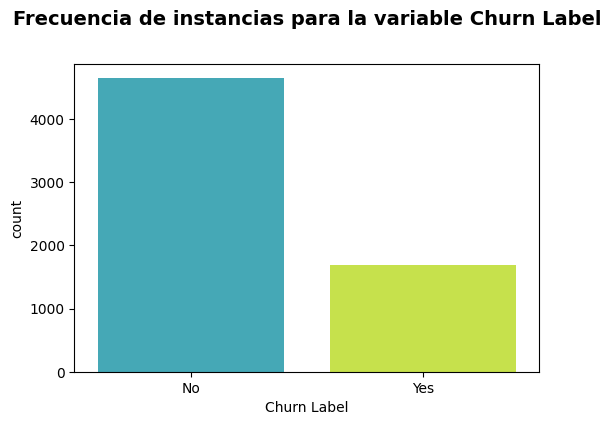

In [112]:
multiple_plot(1, df , None, 'Churn Label', 'countplot', 'Frecuencia de instancias para la variable Churn Label',0)

## 4. Preparación de Datos para el Modelado

### Aplicación de One-Hot Encoding,



Se aplica One-Hot Encoding al DataFrame preparado en la fase de limpieza. Luego, se realiza la división en conjuntos de entrenamiento y el escalado de las variables numéricas.

In [113]:
# Aplicacion de la funcion de usuario Dummies: one-hot encoding

df = pd.get_dummies(df, drop_first=1)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                6326 non-null   int64  
 1   Number of Dependents               6326 non-null   int64  
 2   Zip Code                           6326 non-null   int64  
 3   Latitude                           6326 non-null   float64
 4   Longitude                          6326 non-null   float64
 5   Population                         6326 non-null   int64  
 6   Number of Referrals                6326 non-null   int64  
 7   Tenure in Months                   6326 non-null   int64  
 8   Avg Monthly Long Distance Charges  6326 non-null   float64
 9   Avg Monthly GB Download            6326 non-null   int64  
 10  Monthly Charge                     6326 non-null   float64
 11  Total Charges                      6326 non-null   float64
 12  Tot

In [114]:
# Imprimir todas las variables (columnas) del dataset

print(df.columns.tolist())

['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Married_Yes', 'Referred a Friend_Yes', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No internet', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection Plan_Yes', 'Premium Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year', 'Contract_Two Year', 'Paperless Billing_Yes', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Customer 

Excluimos las variables que se consideran de fuga para evitar datalake

In [115]:
# Definimos las variables de entrada (X) y la variable objetivo (y)
exclude = [
    # leakage
    'Churn Score',
    'CLTV',
    'Total Revenue',
    'Customer Status_Joined',
    'Customer Status_Stayed',
    'Satisfaction Score',

    # target
    'Churn Label_Yes',

    # geo noise
    'Zip Code',
    'Latitude',
    'Longitude',
    'Population',
]

X = df.drop(columns=exclude)
y = df['Churn Label_Yes']

vDep = X.columns.tolist()


In [116]:
# Dividimos los datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1, 1),
    train_size=0.8,
    random_state=123,
    shuffle=True
)


print(f'Shape X_train: {X_train.shape}')
print(f'Shape y_train: {y_train.shape}')
print(f'Shape X_test:  {X_test.shape}')
print(f'Shape y_test:  {y_test.shape}')


Shape X_train: (5060, 39)
Shape y_train: (5060, 1)
Shape X_test:  (1266, 39)
Shape y_test:  (1266, 1)


## 5. Escalado de variables

In [117]:
# Se establecen las variables numéricas a escalar

# Get the list of numerical columns that are actually in X_train
num_vars_to_scale = [col for col in numCols if col in X_train.columns]

print(num_vars_to_scale)

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']


In [118]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars_to_scale] = scaler.fit_transform(X_train[num_vars_to_scale])
X_test[num_vars_to_scale] = scaler.transform(X_test[num_vars_to_scale])

X_test[num_vars_to_scale].head(2)

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges
2579,0.2131,0.0000,0.5455,0.5775,0.0000,0.3059,0.2661,0.2343,0.0000,0.0000,0.0000
1778,0.4426,0.2222,0.3636,0.0845,0.0000,0.3294,0.3114,0.0331,0.0000,0.0000,0.0000


In [119]:
# Guardar el scaler

SCALER_FILE_NAME = 'minmaxFull_Telco.pkl'
local_scaler_path = os.path.join(MODELS_SCALER_PATH, SCALER_FILE_NAME)

joblib.dump(scaler,  local_scaler_path)

['modelos/scaler\\minmaxFull_Telco.pkl']

## 6. Modelado

#### Modelo 1: Regresion logistica

Teniendo en cuenta el desabalance de nuestra variable de salida tomamos como punto de partidas comparar los resultados de nuestros modelos evaluados con balanceo y sin balanceo, establecimos 3 solver enfocados en la regularizacion, eficiencia y flexibilidad manteniendo los mismos parametros para garantizar la estandarizacion del resultado diferenciados por la aplicacion del balanceo de la variable.
modelLRLbfgsB = LogisticRegression( solver="lbfgs",     class_weight="balanced",  max_iter=1000, random_state=123 )
modelLRLineaB = LogisticRegression( solver="liblinear", class_weight="balanced", penalty="l1", max_iter=1000, random_state=123 )
modelLRSagaB = LogisticRegression(  solver="saga",      class_weight="balanced", penalty="elasticnet", l1_ratio=0.2, max_iter=1000, random_state=123 )

En este aplicacion del modelo obtuvimos como mejor resultados el siguiente modelo   SAGA (base)                0.8073     0.5909     0.8614     0.7010 ya que nos arroja el recall mas alto y a su vez tiene mejor resultado en su f1 score.

In [120]:
# Creación del modelo — max_iter=1000 para garantizar convergencia

modelLRLbfgsB = LogisticRegression( solver="lbfgs",     class_weight="balanced",  max_iter=1000, random_state=123 )
modelLRLineaB = LogisticRegression( solver="liblinear", class_weight="balanced", penalty="l1", max_iter=1000, random_state=123 )
modelLRSagaB = LogisticRegression(  solver="saga",      class_weight="balanced", penalty="elasticnet", l1_ratio=0.2, max_iter=1000, random_state=123 )

# Entrenamiento con 80% de training
modelLRLbfgsB.fit(X_train, y_train)
modelLRLineaB.fit(X_train, y_train)
modelLRSagaB.fit(X_train, y_train)

print("Modelo LBFGS:")
print(modelLRLbfgsB)

print("\nModelo Liblinear:")
print(modelLRLineaB)

print("\nModelo SAGA:")
print(modelLRSagaB)

Modelo LBFGS:
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=123)

Modelo Liblinear:
LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=123, solver='liblinear')

Modelo SAGA:
LogisticRegression(class_weight='balanced', l1_ratio=0.2, max_iter=1000,
                   penalty='elasticnet', random_state=123, solver='saga')


In [121]:
# Predicción sobre el conjunto de prueba
y_predLbfgsB = modelLRLbfgsB.predict(X_test)
y_predLineaB = modelLRLineaB.predict(X_test)
y_predSagaB  = modelLRSagaB.predict(X_test)


In [122]:
# Recall para todos los modelos base

print(f"Recall : {recall_score(y_test, y_predLbfgsB):.4f} -> LR L-BFGS (Balanced)")
print(f"Recall : {recall_score(y_test, y_predLineaB):.4f} -> LR Liblinear L1 (Balanced)")
print(f"Recall : {recall_score(y_test, y_predSagaB):.4f}  -> LR SAGA ElasticNet (Balanced)")

Recall : 0.8614 -> LR L-BFGS (Balanced)
Recall : 0.8584 -> LR Liblinear L1 (Balanced)
Recall : 0.8614  -> LR SAGA ElasticNet (Balanced)


Creamos el modelo con los datos desbalanceados para establecer  los comparativos

In [123]:
# Modelos base SIN balanceo (class_weight=None) — punto de partida real desbalanceado

modelLRLbfgsN = LogisticRegression(solver="lbfgs",     max_iter=1000, random_state=123)
modelLRLineaN = LogisticRegression(solver="liblinear", penalty="l1",  max_iter=1000, random_state=123)
modelLRSagaN  = LogisticRegression(solver="saga",      penalty="elasticnet", l1_ratio=0.2, max_iter=1000, random_state=123)

modelLRLbfgsN.fit(X_train, y_train)
modelLRLineaN.fit(X_train, y_train)
modelLRSagaN.fit(X_train,  y_train)

y_predLbfgsN = modelLRLbfgsN.predict(X_test)
y_predLineaN = modelLRLineaN.predict(X_test)
y_predSagaN  = modelLRSagaN.predict(X_test)

# Recall para modelos base sin balanceo (class_weight=None)

print(f"Recall : {recall_score(y_test, y_predLbfgsN):.4f} -> LR L-BFGS (Base-None)")
print(f"Recall : {recall_score(y_test, y_predLineaN):.4f} -> LR Liblinear (Base-None)")
print(f"Recall : {recall_score(y_test, y_predSagaN):.4f}  -> LR SAGA (Base-None)")

Recall : 0.6687 -> LR L-BFGS (Base-None)
Recall : 0.6867 -> LR Liblinear (Base-None)
Recall : 0.6717  -> LR SAGA (Base-None)


## 7. Evaluación Detallada del los Modelos de Regresión Logística (Sin OverSampling)

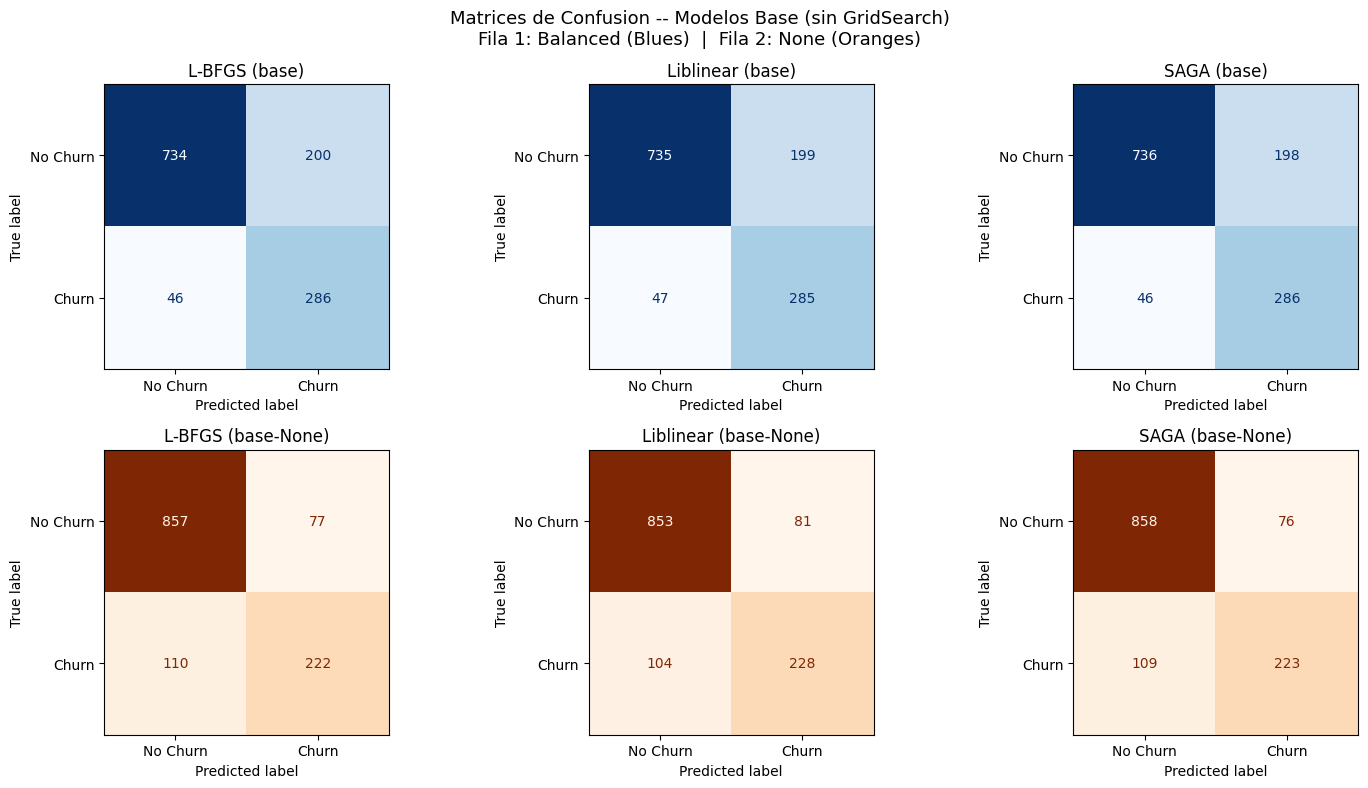

  Solver                   Accuracy  Precision     Recall         F1
  ---------------------- ---------- ---------- ---------- ----------
  L-BFGS (base)              0.8057     0.5885     0.8614     0.6993
  Liblinear (base)           0.8057     0.5888     0.8584     0.6985
  SAGA (base)                0.8073     0.5909     0.8614     0.7010
  L-BFGS (base-None)         0.8523     0.7425     0.6687     0.7036
  Liblinear (base-None)      0.8539     0.7379     0.6867     0.7114
  SAGA (base-None)           0.8539     0.7458     0.6717     0.7068


In [124]:
modelos_base_cm = {
    'L-BFGS (base)':    [modelLRLbfgsB, y_predLbfgsB],
    'Liblinear (base)': [modelLRLineaB, y_predLineaB],
    'SAGA (base)':      [modelLRSagaB,  y_predSagaB],

    'L-BFGS (base-None)':    [modelLRLbfgsN, y_predLbfgsN],
    'Liblinear (base-None)': [modelLRLineaN, y_predLineaN],
    'SAGA (base-None)':      [modelLRSagaN,  y_predSagaN],
}

# Fila 1 (Balanced) → Blues  |  Fila 2 (None) → Oranges
cmaps_cm = ['Blues', 'Blues', 'Blues',
            'Oranges', 'Oranges', 'Oranges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
fig.suptitle('Matrices de Confusion -- Modelos Base (sin GridSearch)\nFila 1: Balanced (Blues)  |  Fila 2: None (Oranges)', fontsize=13)

for ax, (nombre, (model, y_pred)), cmap in zip(axes, modelos_base_cm.items(), cmaps_cm):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

print(f"  {'Solver':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'-'*22} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for nombre, (model, y_pred) in modelos_base_cm.items():
    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test,    y_pred)
    f1   = f1_score(y_test,        y_pred)
    print(f"  {nombre:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")


## 7.1 Curva ROC — Modelos Sin Optimizar

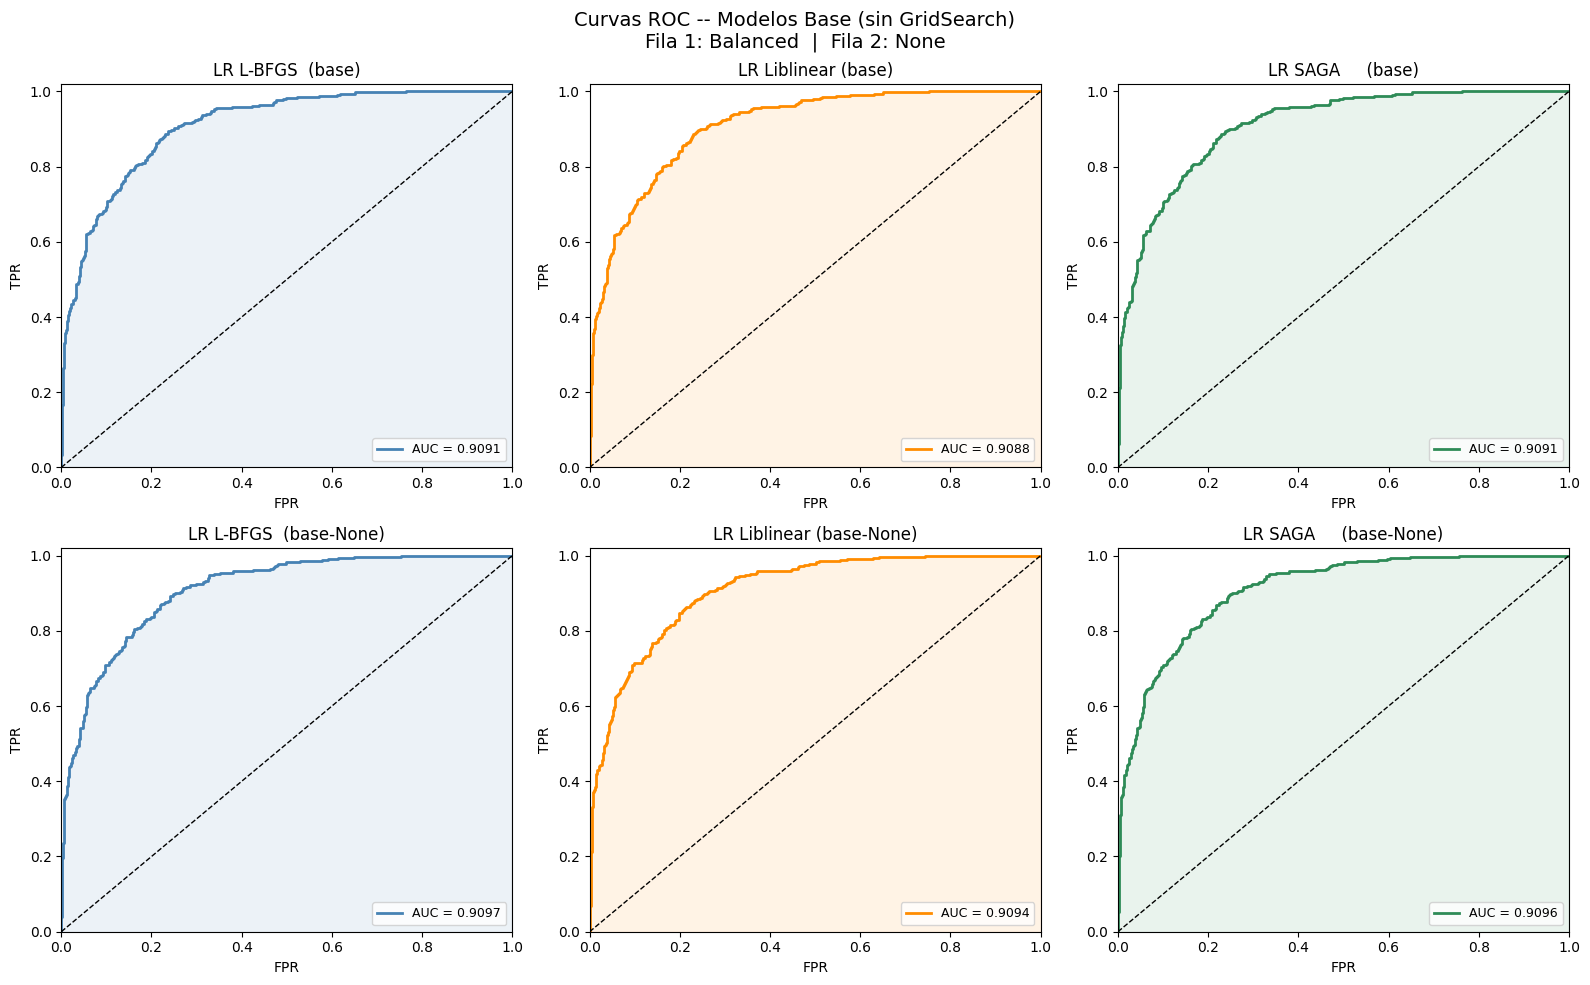

In [125]:
# Curva ROC individual -- modelos base (sin GridSearch)
# Color por solver: steelblue=L-BFGS | darkorange=Liblinear | seagreen=SAGA
# Fila 1: Balanced  |  Fila 2: None

modelos_base_roc = {
    'LR L-BFGS  (base)':         modelLRLbfgsB,
    'LR Liblinear (base)':       modelLRLineaB,
    'LR SAGA     (base)':        modelLRSagaB,
    'LR L-BFGS  (base-None)':    modelLRLbfgsN,
    'LR Liblinear (base-None)':  modelLRLineaN,
    'LR SAGA     (base-None)':   modelLRSagaN,
}

# Un color por solver, repetido para ambas filas (balanced y None)
colores_roc = ['steelblue', 'darkorange', 'seagreen',
               'steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Curvas ROC -- Modelos Base (sin GridSearch)\nFila 1: Balanced  |  Fila 2: None', fontsize=14)

for ax, (nombre, modelo), color in zip(axes, modelos_base_roc.items(), colores_roc):
    y_scores = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.10, color=color)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(nombre)
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


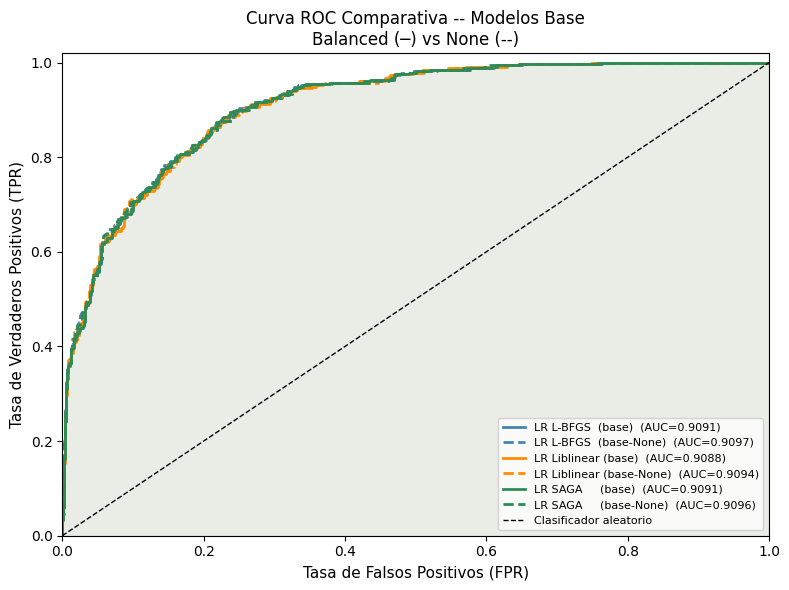

  Solver                              AUC        F1    Recall
  ------------------------------ --------  --------  --------
  LR L-BFGS  (base)                0.9091    0.6993    0.8614
  LR Liblinear (base)              0.9088    0.6985    0.8584
  LR SAGA     (base)               0.9091    0.7010    0.8614
  LR L-BFGS  (base-None)           0.9097    0.7036    0.6687
  LR Liblinear (base-None)         0.9094    0.7114    0.6867
  LR SAGA     (base-None)          0.9096    0.7068    0.6717


In [126]:
# Curva ROC comparativa -- los 6 modelos base en un solo grafico
# Linea solida = class_weight=balanced  |  Linea punteada = class_weight=None

colores_solvers = ['steelblue', 'darkorange', 'seagreen']

# Pares (balanced, none) por solver
pares = [
    ('LR L-BFGS  (base)',     modelLRLbfgsB,  'LR L-BFGS  (base-None)',     modelLRLbfgsN),
    ('LR Liblinear (base)',   modelLRLineaB,  'LR Liblinear (base-None)',   modelLRLineaN),
    ('LR SAGA     (base)',    modelLRSagaB,   'LR SAGA     (base-None)',    modelLRSagaN),
]

fig, ax = plt.subplots(figsize=(8, 6))

for (nombre_b, modelo_b, nombre_n, modelo_n), color in zip(pares, colores_solvers):
    # Balanced — linea solida
    y_scores = modelo_b.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle='-',
            label=f'{nombre_b}  (AUC={auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

    # None — linea punteada
    y_scores = modelo_n.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle='--',
            label=f'{nombre_n}  (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC Comparativa -- Modelos Base\nBalanced (─) vs None (--)', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"  {'Solver':<30} {'AUC':>8}  {'F1':>8}  {'Recall':>8}")
print(f"  {'-'*30} {'-'*8}  {'-'*8}  {'-'*8}")
for nombre, modelo in modelos_base_roc.items():
    y_scores = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_scores)
    f1  = f1_score(y_test, modelo.predict(X_test))
    rec = recall_score(y_test, modelo.predict(X_test))
    print(f"  {nombre:<30} {auc:>8.4f}  {f1:>8.4f}  {rec:>8.4f}")


En términos generales, estos resultados indican que:

- Los modelos base ya presentan un desempeño sólido para detección de churn.
- Existe una buena capacidad discriminativa (AUC alto).
- El modelo prioriza sensibilidad (recall) sobre precisión.


## 8. Optimizacion con grid search

Posteriormente intentamos aplicar una optimización de nuestros modelos mediante una búsqueda de hiperparámetros utilizando Grid Search con validación cruzada. El objetivo fue lograr una relación más equilibrada entre recall y F1-score.

Para ello, incorporamos la técnica de balanceo para ajustar la importancia de las clases,  Adicionalmente, configuramos la variable scoring con recall y f1 como objetivo para evaluar simultaneamente ambas metricas y seleccionar el mejor modelo basado en ambas metricas de tal manera que podamos obtener una alta capacidad de detección de churn.

Como resultado, no se observaron diferencias significativas en el desempeño de los modelos; sin embargo, se logró un modelo más estable y equilibrado, manteniendo una mejor relacio entre la sensibilidad (recall) y el rendimiento global medido por el F1-score.

Resultados previos cuando solo priorizamos recall
  ------------ ---------- ---------- ---------- ----------
  L-BFGS           0.8057     0.5885     0.8614     0.6993

  Liblinear        0.8057     0.5888     0.8584     0.6985

  SAGA             0.8057     0.5885     0.8614     0.6993

Resultados posteriores priorizacion de ambas metricas

Solver         Accuracy  Precision     Recall         F1
  ------------ ---------- ---------- ---------- ----------
  L-BFGS           0.8081     0.5918     0.8645     0.7026

  Liblinear        0.8057     0.5885     0.8614     0.6993

  SAGA             0.8057     0.5885     0.8614     0.6993

Evidenciamos un resultado mas estable en el modelo   
L-BFGS           0.8081     0.5918     0.8645     0.7026 despues de priorizar ambas metricas

In [127]:



# ── Param grids ──────────────────────────────────────────────────────
param_grid_lbfgs = {
    "C": [0.01, 0.1, 1, 10, 100],
}

param_grid_liblinear = {
    "C": [0.01, 0.1, 1, 10, 100],
}

param_grid_saga = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

y_train_1d = y_train.ravel()

# ── Scoring múltiple ─────────────────────────────────────────────────
scoring = {
    'recall': 'recall',
    'f1': 'f1'
}

# ── Config B: class_weight=balanced ──────────────────────────────────
print('--- GridSearch B: class_weight=balanced ---')

gb_lbfgs = GridSearchCV(
    LogisticRegression(
        solver='lbfgs',
        class_weight='balanced',
        random_state=123,
        max_iter=1000
    ),
    param_grid_lbfgs,
    cv=5,
    scoring=scoring,
    refit='f1',
    n_jobs=-1
)

gb_liblinear = GridSearchCV(
    LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        penalty='l1',
        random_state=123,
        max_iter=1000
    ),
    param_grid_liblinear,
    cv=5,
    scoring=scoring,
    refit='f1',
    n_jobs=-1
)

gb_saga = GridSearchCV(
    LogisticRegression(
        solver='saga',
        class_weight='balanced',
        penalty='elasticnet',
        random_state=123,
        max_iter=1000
    ),
    param_grid_saga,
    cv=5,
    scoring=scoring,
    refit='f1',
    n_jobs=-1
)

# ── Fit ──────────────────────────────────────────────────────────────
gb_lbfgs.fit(X_train, y_train_1d)
gb_liblinear.fit(X_train, y_train_1d)
gb_saga.fit(X_train, y_train_1d)

# ── Predicciones ─────────────────────────────────────────────────────
yb_lbfgs = gb_lbfgs.best_estimator_.predict(X_test)
yb_liblinear = gb_liblinear.best_estimator_.predict(X_test)
yb_saga = gb_saga.best_estimator_.predict(X_test)


grid_lbfgs, grid_liblinear, grid_saga = gb_lbfgs, gb_liblinear, gb_saga

best_lbfgs = gb_lbfgs.best_estimator_
best_liblinear = gb_liblinear.best_estimator_
best_saga = gb_saga.best_estimator_

y_pred_lbfgs_opt = yb_lbfgs
y_pred_liblinear_opt = yb_liblinear
y_pred_saga_opt = yb_saga

print('Listo.')

--- GridSearch B: class_weight=balanced ---
Listo.


In [128]:
from sklearn.metrics import f1_score, recall_score, precision_score

print('=' * 95)
print(' class_weight=balanced  (scoring=recall)')
print('=' * 95)
ancho = 11
hdr = (f'  {"Solver":<11}  {"Recall base":>{ancho}}'
      # f'  {"── None ──":^{ancho*2+4}}'
       f'  {"── Balanced ──":^{ancho*2+4}}')
print(hdr)
hdr2 = (f'  {"":11}  {"":>{ancho}}'
       # f'  {"Recall opt":>{ancho}}  {"F1":>{ancho}}'
        f'  {"Recall opt":>{ancho}}  {"F1":>{ancho}}')
print(hdr2)
print(f'  {"-"*11}  {"-"*ancho}  {"-"*ancho}  {"-"*ancho}  {"-"*ancho}  {"-"*ancho}')

configs = [
    ('L-BFGS',    y_predLbfgsB,     yb_lbfgs),
    ('Liblinear', y_predLineaB,   yb_liblinear),
    ('SAGA',      y_predSagaB,       yb_saga),
]

for solver, y_base,  yb in configs:
    rec_base = recall_score(y_test, y_base)
    #rec_a    = recall_score(y_test, ya)
    #f1a      = f1_score(y_test, ya)
    rec_b    = recall_score(y_test, yb)
    f1b      = f1_score(y_test, yb)
    print(f'  {solver:<11}  {rec_base:>{ancho}.4f}'
         # f'  {rec_a:>{ancho}.4f}  {f1a:>{ancho}.4f}'
          f'  {rec_b:>{ancho}.4f}  {f1b:>{ancho}.4f}')

print()
print()
print('  Mejores parametros:')
for nombre,  gb in [('L-BFGS',  gb_lbfgs), ('Liblinear',  gb_liblinear), ('SAGA',  gb_saga)]:
    print(f'    {nombre:<11}   Balanced={gb.best_params_}')

 class_weight=balanced  (scoring=recall)
  Solver       Recall base        ── Balanced ──      
                             Recall opt           F1
  -----------  -----------  -----------  -----------  -----------  -----------
  L-BFGS            0.8614       0.8645       0.7026
  Liblinear         0.8584       0.8614       0.6993
  SAGA              0.8614       0.8614       0.6993


  Mejores parametros:
    L-BFGS        Balanced={'C': 100}
    Liblinear     Balanced={'C': 100}
    SAGA          Balanced={'C': 100, 'l1_ratio': 0.5}



CONFIGURACION: class_weight=Balanced (maximiza Recall)


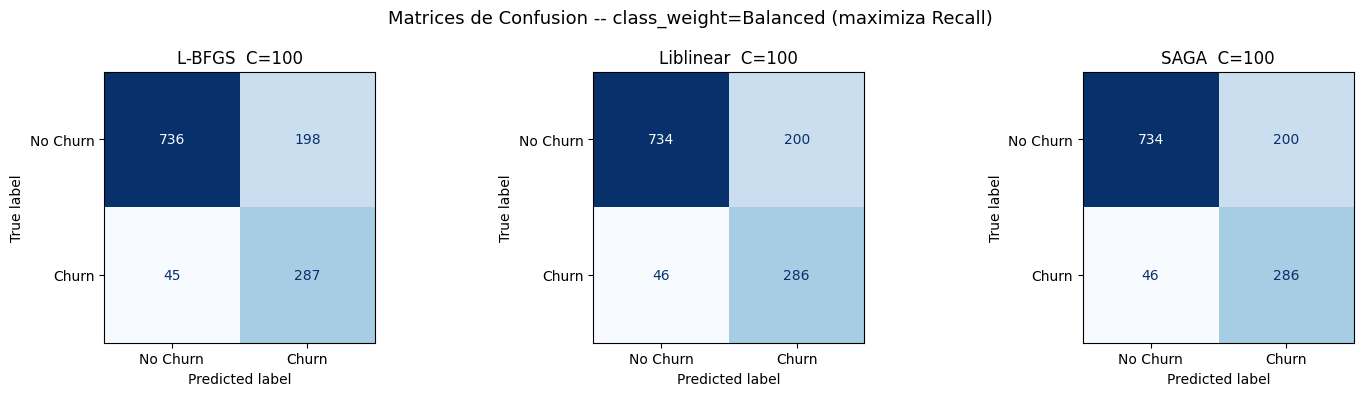

  Solver         Accuracy  Precision     Recall         F1
  ------------ ---------- ---------- ---------- ----------
  L-BFGS           0.8081     0.5918     0.8645     0.7026
  Liblinear        0.8057     0.5885     0.8614     0.6993
  SAGA             0.8057     0.5885     0.8614     0.6993



In [129]:
# Evaluacion de ambas configuraciones GridSearch
# Config A: class_weight=None  |  Config B: class_weight=balanced

configs = [
    # {
    #     'label': 'None (maximiza Recall sin balance)',
    #     'color': 'Oranges',
    #     'modelos': [
    #         ('L-BFGS',    ga_lbfgs.best_estimator_,    ya_lbfgs),
    #         ('Liblinear', ga_liblinear.best_estimator_, ya_liblinear),
    #         ('SAGA',      ga_saga.best_estimator_,      ya_saga),
    #     ]
    # },
    {
        'label': 'Balanced (maximiza Recall)',
        'color': 'Blues',
        'modelos': [
            ('L-BFGS',    gb_lbfgs.best_estimator_,    yb_lbfgs),
            ('Liblinear', gb_liblinear.best_estimator_, yb_liblinear),
            ('SAGA',      gb_saga.best_estimator_,      yb_saga),
        ]
    },
]

for cfg in configs:
    print()
    print('=' * 70)
    print(f"CONFIGURACION: class_weight={cfg['label']}")
    print('=' * 70)

    # Matrices de confusion lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Matrices de Confusion -- class_weight={cfg['label']}", fontsize=13)

    for ax, (solver, model, y_pred) in zip(axes, cfg['modelos']):
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
            ax=ax, cmap=cfg['color'], colorbar=False
        )
        ax.set_title(f'{solver}  C={model.C}')

    plt.tight_layout()
    plt.show()

    # Tabla de metricas
    print(f"  {'Solver':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
    for solver, model, y_pred in cfg['modelos']:
        acc  = accuracy_score(y_test,  y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test,    y_pred)
        f1   = f1_score(y_test,        y_pred)
        print(f"  {solver:<12} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    print()


## 10. Curva ROC — Modelos Optimizados

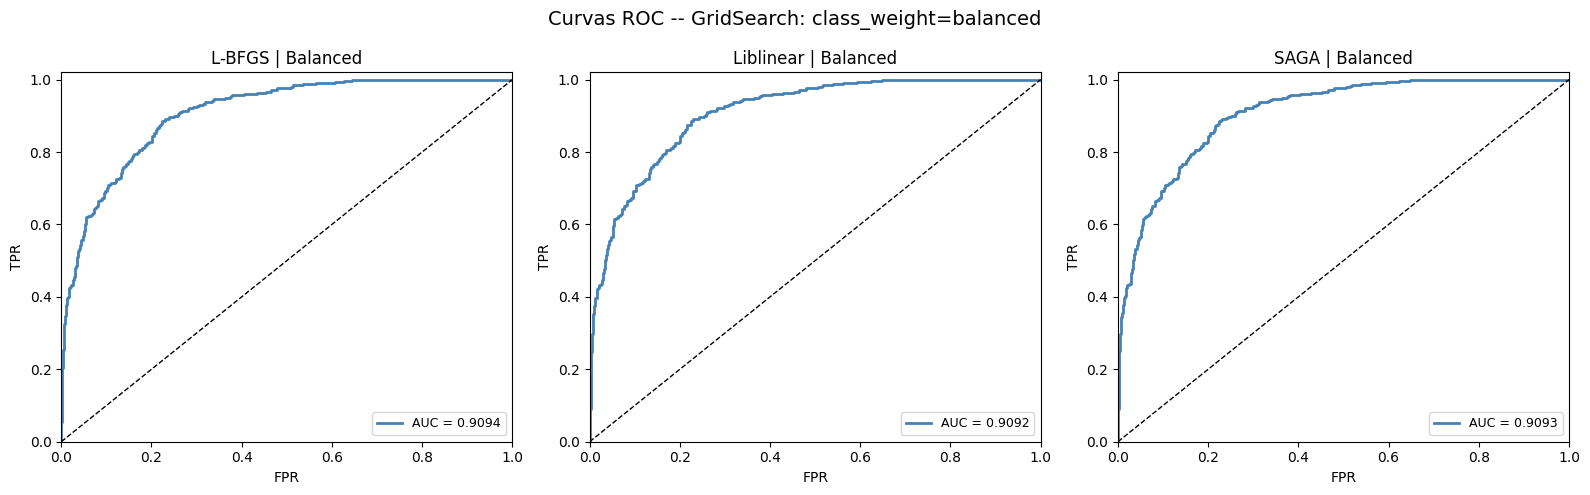

In [130]:
configs_roc = [
    ('Balanced', 'Blues_r', [
        ('L-BFGS',    gb_lbfgs.best_estimator_),
        ('Liblinear', gb_liblinear.best_estimator_),
        ('SAGA',      gb_saga.best_estimator_),
    ]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Curvas ROC -- GridSearch: class_weight=balanced', fontsize=14)

for col, (solver, modelo) in enumerate(configs_roc[0][2]):
    ax = axes[col]

    y_scores = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)

    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'{solver} | Balanced')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

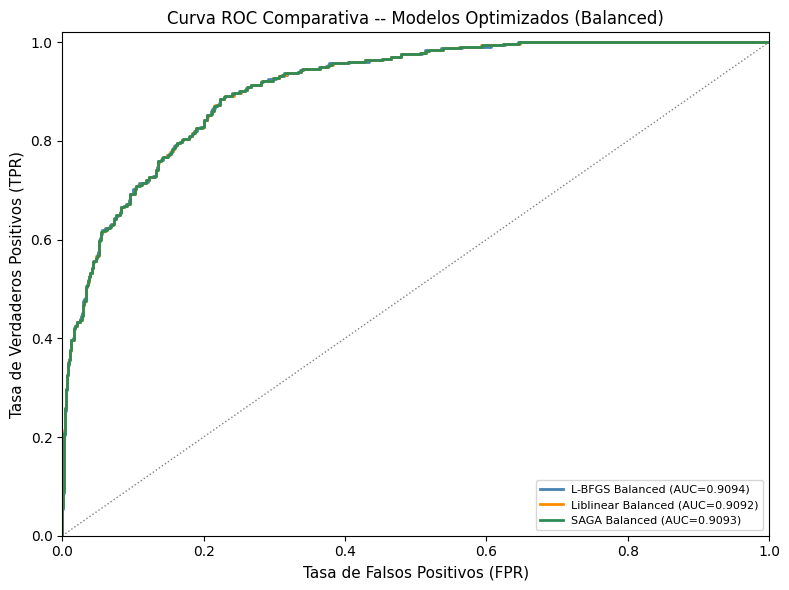

In [131]:
# Curva ROC -- Modelos Optimizados (Balanced)

colores = ['steelblue', 'darkorange', 'seagreen']
solvers = ['L-BFGS', 'Liblinear', 'SAGA']


modelos_bal  = [gb_lbfgs.best_estimator_, gb_liblinear.best_estimator_, gb_saga.best_estimator_]

fig, ax = plt.subplots(figsize=(8, 6))


for solver, modelo_b, color in zip(solvers, modelos_bal, colores):
    # Plot 'Balanced' models with a solid line
    y_scores = modelo_b.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle='-',
            label=f'{solver} Balanced (AUC={auc:.4f})')

ax.plot([0,1],[0,1], color='gray', lw=1, linestyle=':')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC Comparativa -- Modelos Optimizados (Balanced)', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [132]:
# Variables 1D

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Grupo Optimizado = class_weight=None (maximiza F1)
# Grupo Oversampling = modelos entrenados con RandomOverSampler
# Todos los modelos se evaluan sobre el mismo X_test / y_test para comparacion justa
grupos_modelos = [
    ("LR L-BFGS  (base)",          modelLRLbfgsB,                X_test, y_test, "Base"),
    ("LR Liblinear (base)",         modelLRLineaB,                X_test, y_test, "Base"),
    ("LR SAGA     (base)",          modelLRSagaB,                 X_test, y_test, "Base"),
    ("LR L-BFGS  (base-None)",     modelLRLbfgsN,                X_test, y_test, "Base-None"),
    ("LR Liblinear (base-None)",   modelLRLineaN,                X_test, y_test, "Base-None"),
    ("LR SAGA     (base-None)",    modelLRSagaN,                 X_test, y_test, "Base-None"),
    #("LR L-BFGS  (opt-None)",       ga_lbfgs.best_estimator_,    X_test, y_test, "Optimizado"),
    #("LR Liblinear (opt-None)",     ga_liblinear.best_estimator_, X_test, y_test, "Optimizado"),
    #("LR SAGA     (opt-None)",      ga_saga.best_estimator_,      X_test, y_test, "Optimizado"),
    ("LR L-BFGS  (opt-Balanced)",   gb_lbfgs.best_estimator_,    X_test, y_test, "Opt-Balanced"),
    ("LR Liblinear (opt-Balanced)", gb_liblinear.best_estimator_, X_test, y_test, "Opt-Balanced"),
    ("LR SAGA     (opt-Balanced)",  gb_saga.best_estimator_,      X_test, y_test, "Opt-Balanced"),

]

resultados = []
for nombre, modelo, Xt, yt, grupo in grupos_modelos:
    y_pred = modelo.predict(Xt)
    y_prob = modelo.predict_proba(Xt)[:, 1]
    resultados.append({
        "Modelo":    nombre,
        "Grupo":     grupo,
        "Accuracy":  accuracy_score(yt, y_pred),
        "Precision": precision_score(yt, y_pred),
        "Recall":    recall_score(yt, y_pred),
        "F1":        f1_score(yt, y_pred),
        "AUC":       roc_auc_score(yt, y_prob),
    })

df_comp = pd.DataFrame(resultados).set_index('Modelo')

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_colwidth', None)
print('=' * 90)
print('COMPARATIVA FINAL -- TODOS LOS MODELOS')
print('=' * 90)
display(df_comp)


COMPARATIVA FINAL -- TODOS LOS MODELOS


,Grupo,Accuracy,Precision,Recall,F1,AUC
Modelo,,,,,,
LR L-BFGS (base),Base,0.8057,0.5885,0.8614,0.6993,0.9091
LR Liblinear (base),Base,0.8057,0.5888,0.8584,0.6985,0.9088
LR SAGA (base),Base,0.8073,0.5909,0.8614,0.7010,0.9091
LR L-BFGS (base-None),Base-None,0.8523,0.7425,0.6687,0.7036,0.9097
LR Liblinear (base-None),Base-None,0.8539,0.7379,0.6867,0.7114,0.9094
LR SAGA (base-None),Base-None,0.8539,0.7458,0.6717,0.7068,0.9096
LR L-BFGS (opt-Balanced),Opt-Balanced,0.8081,0.5918,0.8645,0.7026,0.9094
LR Liblinear (opt-Balanced),Opt-Balanced,0.8057,0.5885,0.8614,0.6993,0.9092
LR SAGA (opt-Balanced),Opt-Balanced,0.8057,0.5885,0.8614,0.6993,0.9093


In [133]:
# Verificacion de overfitting - Train Accuracy vs Test Accuracy

def nivel_overfit(diff):
    if diff <= 0.01:  return "Sin overfitting"
    if diff <= 0.03:  return "Overfitting leve"
    if diff <= 0.05:  return "Overfitting moderado"
    return "Overfitting alto"

y_train_1d_eval = y_train.ravel()
y_test_1d_eval  = y_test.ravel()

print(f"  {'Modelo':<28} {'Train Acc':>10} {'Test Acc':>10} {'Diferencia':>12} {'Observacion':<22}")
print(f"  {'-'*28} {'-'*10} {'-'*10} {'-'*12} {'-'*22}")

for nombre, modelo, _, _, grupo in grupos_modelos:
    tr_acc = accuracy_score(y_train_1d_eval, modelo.predict(X_train))
    te_acc = accuracy_score(y_test_1d_eval,  modelo.predict(X_test))
    diff   = tr_acc - te_acc
    obs    = nivel_overfit(diff)
    print(f"  {nombre:<28} {tr_acc:>10.4f} {te_acc:>10.4f} {diff:>12.4f} {obs:<22}")


  Modelo                        Train Acc   Test Acc   Diferencia Observacion           
  ---------------------------- ---------- ---------- ------------ ----------------------
  LR L-BFGS  (base)                0.7945     0.8057      -0.0112 Sin overfitting       
  LR Liblinear (base)              0.7955     0.8057      -0.0102 Sin overfitting       
  LR SAGA     (base)               0.7955     0.8073      -0.0118 Sin overfitting       
  LR L-BFGS  (base-None)           0.8441     0.8523      -0.0082 Sin overfitting       
  LR Liblinear (base-None)         0.8455     0.8539      -0.0084 Sin overfitting       
  LR SAGA     (base-None)          0.8443     0.8539      -0.0096 Sin overfitting       
  LR L-BFGS  (opt-Balanced)        0.7951     0.8081      -0.0130 Sin overfitting       
  LR Liblinear (opt-Balanced)      0.7951     0.8057      -0.0106 Sin overfitting       
  LR SAGA     (opt-Balanced)       0.7955     0.8057      -0.0102 Sin overfitting       


## 12. Exportacion de Modelos

Se exportan todos los modelos entrenados en formato `.pkl` usando `joblib`.


In [134]:
# Se guardan los modelos de Regresion Logistica
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)

# Modelos base
MODEL_FILE_NAME = 'lr_lbfgs_base.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRLbfgsB, local_model_path)

MODEL_FILE_NAME = 'lr_liblinear_base.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRLineaB, local_model_path)

MODEL_FILE_NAME = 'lr_saga_base.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRSagaB, local_model_path)

# Modelos base none
MODEL_FILE_NAME = 'lr_lbfgs_base_none.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRLbfgsN, local_model_path)

MODEL_FILE_NAME = 'lr_liblinear_base_none.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRLineaN, local_model_path)

MODEL_FILE_NAME = 'lr_saga_base_none.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(modelLRSagaN, local_model_path)

# # Modelos optimizados GridSearch class_weight=None (mayor F1)
# MODEL_FILE_NAME = 'lr_lbfgs_opt_none.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(ga_lbfgs.best_estimator_, local_model_path)

# MODEL_FILE_NAME = 'lr_liblinear_opt_none.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(ga_liblinear.best_estimator_, local_model_path)

# MODEL_FILE_NAME = 'lr_saga_opt_none.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(ga_saga.best_estimator_, local_model_path)

# Modelos optimizados GridSearch class_weight=balanced (mayor Recall)
MODEL_FILE_NAME = 'lr_lbfgs_opt_balanced.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(gb_lbfgs.best_estimator_, local_model_path)

MODEL_FILE_NAME = 'lr_liblinear_opt_balanced.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(gb_liblinear.best_estimator_, local_model_path)

MODEL_FILE_NAME = 'lr_saga_opt_balanced.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
joblib.dump(gb_saga.best_estimator_, local_model_path)

# # Modelos con Oversampling
# MODEL_FILE_NAME = 'lr_lbfgs_oversampling.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(modelLRLbfgsRes, local_model_path)

# MODEL_FILE_NAME = 'lr_liblinear_oversampling.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(modelLRLineaRes, local_model_path)

# MODEL_FILE_NAME = 'lr_saga_oversampling.pkl'
# local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)
# joblib.dump(modelLRSagaRes, local_model_path)

print(f'Modelos guardados en: {os.path.abspath(MODELS_CLASIFICACION_PATH)}')


Modelos guardados en: c:\Users\ansal\OneDrive\Documentos\Esp. Analitica y ciencia de datos\Semestre_1\Aprendizaje_Automatico\Modelo_Churn\modelos\clasificacion
